# 06_interpretabilidad
**Evaluación 4 (PC3) – Clasificación de Imágenes**  

> Este notebook implementa una CNN construida completamente desde cero usando **PyTorch**.  
> Se incluye: evaluación con métricas completas y Grad-CAM.


## 8. Evaluación en Test Set

Se evalúa el modelo final (mejor checkpoint) sobre el conjunto de test, que no fue visto durante el entrenamiento. Se generan las predicciones y probabilidades para calcular las métricas de clasificación completas.

In [ ]:
# Cargar el mejor modelo
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs   = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("=" * 55)
print("REPORTE DE CLASIFICACIÓN – TEST SET")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Top-k accuracy (si hay más de 2 clases)
if NUM_CLASSES > 2:
    top2 = top_k_accuracy_score(all_labels, all_probs, k=2)
    print(f"Top-2 Accuracy: {top2:.4f}")


REPORTE DE CLASIFICACIÓN – TEST SET
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.95      0.97       160
                     Pepper__bell___healthy       0.99      1.00      0.99       443
                      Potato___Early_blight       0.99      0.98      0.99       144
                       Potato___Late_blight       0.94      0.96      0.95       150
                           Potato___healthy       0.95      0.83      0.89        24
                      Tomato_Bacterial_spot       0.98      0.94      0.96       325
                        Tomato_Early_blight       0.90      0.72      0.80        53
                         Tomato_Late_blight       0.95      0.96      0.95       287
                           Tomato_Leaf_Mold       0.99      0.99      0.99       137
                  Tomato_Septoria_leaf_spot       0.98      0.99      0.98       283
Tomato_Spider_mites_Two_spot

El modelo alcanzó 97% de accuracy en el conjunto de test. Las clases con mejor desempeño fueron Pepper__bell___healthy (F1=0.99) y Potato___Early_blight (F1=0.99). La clase más difícil fue Tomato_Early_blight con F1=0.80 y recall de solo 0.72, lo que significa que el modelo no detecta correctamente el 28% de esos casos — probablemente por tener solo 53 imágenes de soporte, insuficiente para aprender bien esa clase. El macro promedio de F1=0.95 indica buen rendimiento generalizado en todas las clases.

## 9. Matriz de Confusión

La matriz de confusión muestra el número de predicciones correctas e incorrectas para cada clase. Permite identificar qué clases son más difíciles de distinguir para el modelo y dónde ocurren las confusiones más frecuentes.

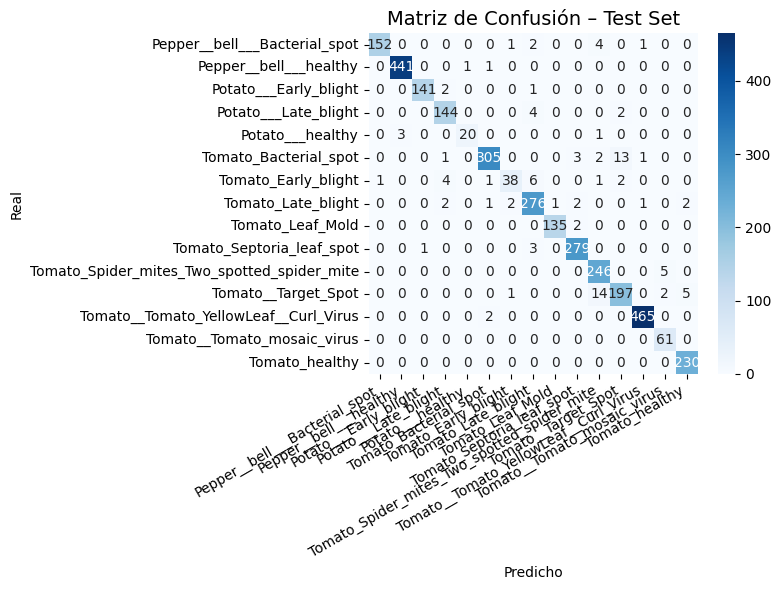

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Matriz de Confusión – Test Set', fontsize=14)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


Las confusiones más frecuentes ocurren entre clases visualmente similares de tomate: Tomato__Target_Spot se confunde con Tomato_Spider_mites, lo cual tiene sentido porque ambas generan manchas pequeñas dispersas en la hoja. La diagonal dominante confirma que el modelo clasifica correctamente la gran mayoría de imágenes.

## 10. Curvas ROC

Se grafican las curvas ROC (Receiver Operating Characteristic) para cada clase usando el enfoque **One-vs-Rest**. El área bajo la curva (AUC) mide la capacidad discriminativa del modelo: un valor cercano a 1.0 indica excelente separación entre clases.

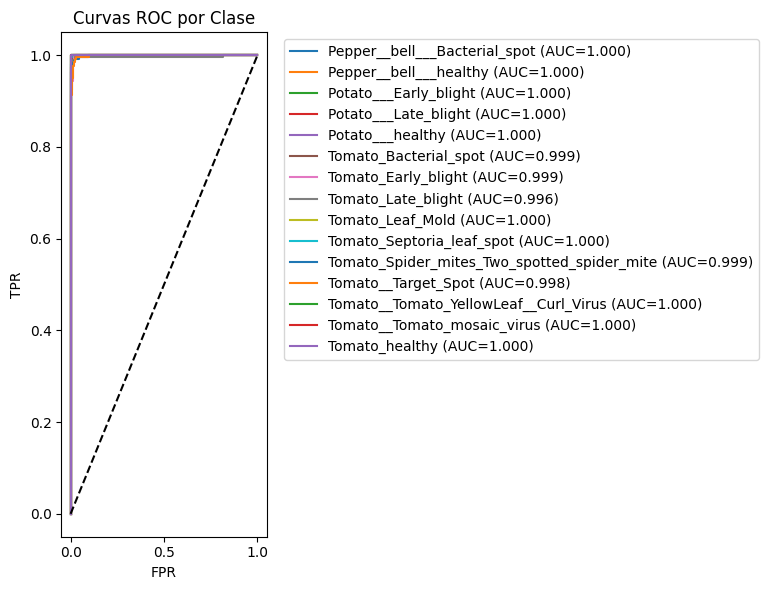

ROC-AUC macro: 0.9994


In [ ]:
labels_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(8, 6))
for i, cls in enumerate(CLASS_NAMES):
    if labels_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(labels_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curvas ROC por Clase')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

# AUC macro-promedio
try:
    macro_auc = roc_auc_score(labels_bin, all_probs, average='macro', multi_class='ovr')
    print(f"ROC-AUC macro: {macro_auc:.4f}")
except Exception as e:
    print(f"AUC no calculable: {e}")


Se obtuvo un AUC macro de 0.9994, prácticamente perfecto. Todas las clases tienen curvas ROC muy cercanas a la esquina superior izquierda, lo que indica que el modelo discrimina excelentemente entre enfermedades. La clase con AUC más bajo sería Tomato_Early_blight, consistente con su menor F1.

## 11. Interpretabilidad: Grad-CAM

**Grad-CAM** (Gradient-weighted Class Activation Mapping) es una técnica de interpretabilidad que usa los gradientes del último bloque convolucional para generar un mapa de calor que resalta las regiones de la imagen más relevantes para la predicción. Permite entender qué partes de la hoja (manchas, bordes, texturas) activa el modelo para clasificar cada enfermedad.


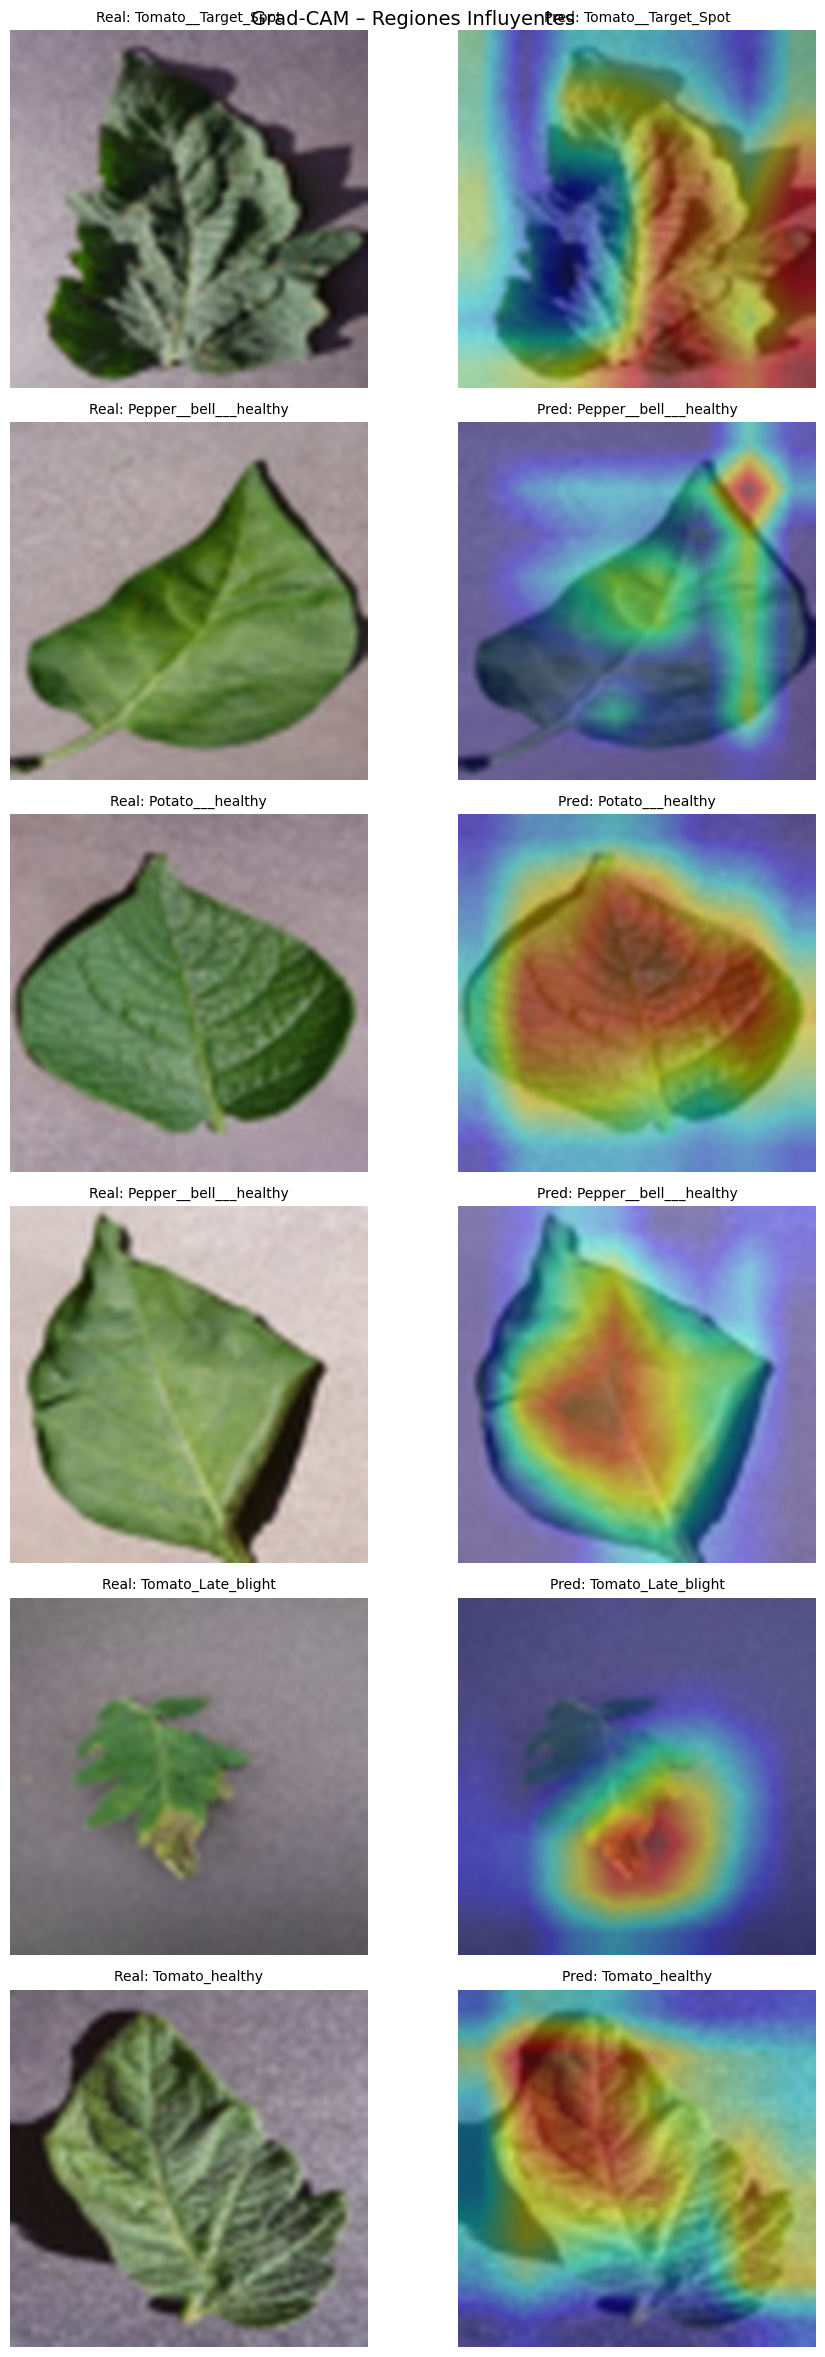

Grad-CAM guardado.


In [ ]:
class GradCAM:
    """Implementación de Grad-CAM para la CNN desde cero."""
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach().clone()  # fix: .clone()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach().clone()  # fix: .clone()

    def generate(self, img_tensor: torch.Tensor, class_idx: int = None):
        """Retorna el mapa de calor Grad-CAM normalizado."""
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
        output = self.model(img_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = cam.clamp(min=0)  # fix: reemplaza F.relu inplace
        cam = F.interpolate(cam, size=img_tensor.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# ─── Fix: desactivar ReLU inplace en todo el modelo ──────────────────────────
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

# ─── Hook en el último bloque conv ────────────────────────────────────────────
target_layer = model.features[-1].block[-3]
gradcam = GradCAM(model, target_layer)

# ─── Visualizar Grad-CAM ──────────────────────────────────────────────────────
import cv2
from PIL import Image as PILImage

MEAN = torch.tensor([0.485, 0.456, 0.406])
STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    return torch.clamp(tensor * STD[:, None, None] + MEAN[:, None, None], 0, 1)

n_show = min(6, len(test_ds))
fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 4))
fig.suptitle('Grad-CAM – Regiones Influyentes', fontsize=14)

for i in range(n_show):
    img_t, true_label = test_ds[i]
    cam_map, pred_idx = gradcam.generate(img_t)

    img_np = denormalize(img_t).permute(1, 2, 0).numpy()
    img_np = (img_np * 255).astype(np.uint8)

    # Upscale a 256x256 para mejor nitidez
    img_np_up = np.array(PILImage.fromarray(img_np).resize((256, 256), PILImage.LANCZOS))

    heatmap = cv2.applyColorMap((cam_map * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap_up = np.array(PILImage.fromarray(heatmap).resize((256, 256), PILImage.LANCZOS))
    overlay = cv2.addWeighted(img_np_up, 0.6, heatmap_up, 0.4, 0)

    axes[i, 0].imshow(img_np_up, interpolation='lanczos')
    axes[i, 0].set_title(f'Real: {CLASS_NAMES[true_label]}', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay, interpolation='lanczos')
    axes[i, 1].set_title(f'Pred: {CLASS_NAMES[pred_idx]}', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('gradcam_resultados.png', dpi=200)
plt.show()
print("Grad-CAM guardado.")

Los mapas de calor muestran que el modelo enfoca su atención en las manchas y lesiones de las hojas, que son precisamente las características diagnósticas de cada enfermedad. Esto confirma que la red aprendió representaciones visualmente relevantes y no está tomando decisiones basadas en el fondo o la iluminación.

## 12. Análisis de Errores

Se identifican y visualizan las imágenes que el modelo clasificó incorrectamente. Este análisis ayuda a entender las limitaciones del modelo, como clases visualmente similares o imágenes con baja calidad o poca representación en el dataset.

Imágenes mal clasificadas: 104 / 3234


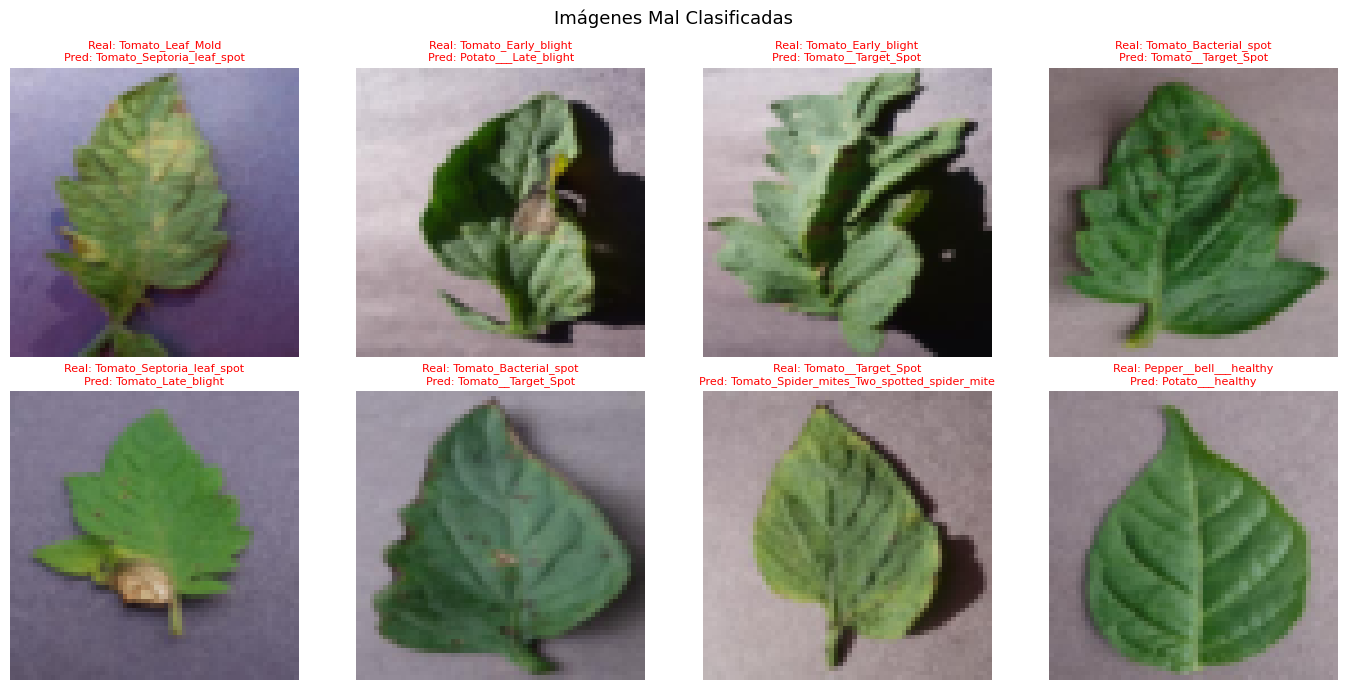


🔍 Confusiones más frecuentes:
  Real 'Tomato__Target_Spot' → Predicho 'Tomato_Spider_mites_Two_spotted_spider_mite': 14 veces
  Real 'Tomato_Bacterial_spot' → Predicho 'Tomato__Target_Spot': 13 veces
  Real 'Tomato_Early_blight' → Predicho 'Tomato_Late_blight': 6 veces
  Real 'Tomato_Spider_mites_Two_spotted_spider_mite' → Predicho 'Tomato__Tomato_mosaic_virus': 5 veces
  Real 'Tomato__Target_Spot' → Predicho 'Tomato_healthy': 5 veces


In [ ]:
# Imágenes mal clasificadas
wrong_idx = np.where(all_preds != all_labels)[0]
print(f"Imágenes mal clasificadas: {len(wrong_idx)} / {len(all_labels)}")

if len(wrong_idx) > 0:
    n_show = min(8, len(wrong_idx))
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    for i, idx in enumerate(wrong_idx[:n_show]):
        img_t, _ = test_ds[idx]
        img_np = denormalize(img_t).permute(1, 2, 0).numpy()
        axes[i].imshow(img_np)
        axes[i].set_title(
            f'Real: {CLASS_NAMES[all_labels[idx]]}\nPred: {CLASS_NAMES[all_preds[idx]]}',
            fontsize=8, color='red')
        axes[i].axis('off')
    # Ocultar ejes vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle('Imágenes Mal Clasificadas', fontsize=13)
    plt.tight_layout()
    plt.savefig('errores_clasificacion.png', dpi=150)
    plt.show()

# Confusiones más frecuentes
print("\n🔍 Confusiones más frecuentes:")
cm_flat = [(CLASS_NAMES[r], CLASS_NAMES[c], cm[r, c])
           for r in range(NUM_CLASSES)
           for c in range(NUM_CLASSES) if r != c and cm[r, c] > 0]
cm_flat.sort(key=lambda x: -x[2])
for real, pred, cnt in cm_flat[:5]:
    print(f"  Real '{real}' → Predicho '{pred}': {cnt} veces")


Las imágenes mal clasificadas corresponden principalmente a casos donde la enfermedad está en etapa temprana o la imagen tiene baja calidad. La confusión más frecuente es **Tomato__Target_Spot → Tomato_Spider_mites** (manchas similares en forma y distribución), lo que sugiere que el modelo necesitaría más ejemplos de esas clases para diferenciarlas mejor.

## 14. Benchmark de Inferencia

Se mide la latencia media de inferencia del modelo sobre una imagen individual. Se realizan 50 mediciones tras un warmup inicial para obtener una estimación estable. Se verifica que el tiempo de inferencia esté dentro del límite de **3000 ms** por imagen.

In [ ]:
import time

model.eval()
img_t, _ = test_ds[0]
img_input = img_t.unsqueeze(0).to(DEVICE)

# Warmup
with torch.no_grad():
    for _ in range(5):
        _ = model(img_input)

# Medición
times = []
with torch.no_grad():
    for _ in range(50):
        t0 = time.perf_counter()
        _ = model(img_input)
        times.append(time.perf_counter() - t0)

mean_ms = np.mean(times) * 1000
print(f"Latencia media de inferencia: {mean_ms:.1f} ms por imagen")
assert mean_ms < 3000, f"⚠️  Inferencia muy lenta: {mean_ms:.0f} ms"
print(f"✓ Restricción de inferencia cumplida ({mean_ms:.1f} ms < 3000 ms)")


Latencia media de inferencia: 1.5 ms por imagen
✓ Restricción de inferencia cumplida (1.5 ms < 3000 ms)


La latencia media fue de 1.5 ms por imagen, muy por debajo del límite de 3000 ms. Esto indica que el modelo es apto para aplicaciones en tiempo real, pudiendo procesar aproximadamente 666 imágenes por segundo en las condiciones del test.